In [11]:
import pandas as pd
import numpy as np

In [12]:
train_data = pd.read_csv("data/train.csv")
validation_data = pd.read_csv("data/validation.csv")
test_data = pd.read_csv("data/test.csv")

print(f"Shape of train_data is : {train_data.shape}")
print(f"Shape of validation_data is : {validation_data.shape}")
print(f"Shape of test_data is : {test_data.shape}")
train_data.head()

Shape of train_data is : (7827, 14)
Shape of validation_data is : (870, 14)
Shape of test_data is : (967, 14)


,Unnamed,team,opp,host,year,month,toss,day_match,bat_first,format,fow,score,rpo,result
0,4901,australia,south_africa,sri_lanka,2012,sep,1,0,0,1,5,146,7.30,1
1,1910,india,australia,india,2020,jan,0,0,1,0,6,340,6.80,1
2,5735,canada,scotland,scotland,2009,jul,1,1,0,0,4,286,5.72,1
3,2136,australia,england,australia,1987,jan,1,1,1,0,6,225,4.50,1
4,4371,new_zealand,pakistan,uae,2009,nov,0,0,0,1,5,153,7.65,0


In [14]:
from utils import convertCategoricalColumnsToOneHotEncoding, pre_process

# Step 2: Encode the columns["Unnamed", "team", "opp", "host", "month"]
continuous_cols = ["Unnamed", "year", "fow", "score", "rpo"]
categorical_cols = ["team", "opp", "host", "month"]

trainDataX, trainDataY, validationDataX, validationDataY, testDataX, testDataY =  pre_process(train_data, validation_data, test_data, categorical_cols = categorical_cols, continuous_cols = continuous_cols)
trainDataX.head()

After pre-processing
Shape of trainDataX is : (7827, 13)
Shape of trainDataY is : (7827,)
Shape of testDataX is : (967, 13)
Shape of testDataY is : (967,)
Shape of validationDataX is : (870, 13)
Shape of validationDataY is : (870,)


,Unnamed,team,opp,host,year,month,toss,day_match,bat_first,format,fow,score,rpo
0,0.023176,0,0,0,0.527774,0,1,0,0,1,-1.226069,-1.161778,0.976509
1,-1.050706,1,1,1,1.215295,1,0,0,1,0,-0.742084,1.817869,0.696053
2,0.322613,2,2,2,0.269953,2,1,1,0,0,-1.710053,0.988483,0.090266
3,-0.969563,0,3,3,-1.620731,1,1,1,1,0,-0.742084,0.051583,-0.594049
4,-0.167114,3,4,4,0.269953,3,0,0,0,1,-1.226069,-1.054265,1.172829


=== Running DecisionTreeClassifier with criterion='entropy' (Varying max_depth) ===

2025-10-23 13:45:39 - Depth=15 | Train Acc=0.8301 | Val Acc=0.6207 | Test Acc=0.6298
2025-10-23 13:45:39 - Depth=25 | Train Acc=0.9825 | Val Acc=0.6138 | Test Acc=0.6101
2025-10-23 13:45:39 - Depth=35 | Train Acc=1.0000 | Val Acc=0.6299 | Test Acc=0.6143
2025-10-23 13:45:39 - Depth=45 | Train Acc=1.0000 | Val Acc=0.6299 | Test Acc=0.6143

 Done! Use validation accuracy to choose the best depth.



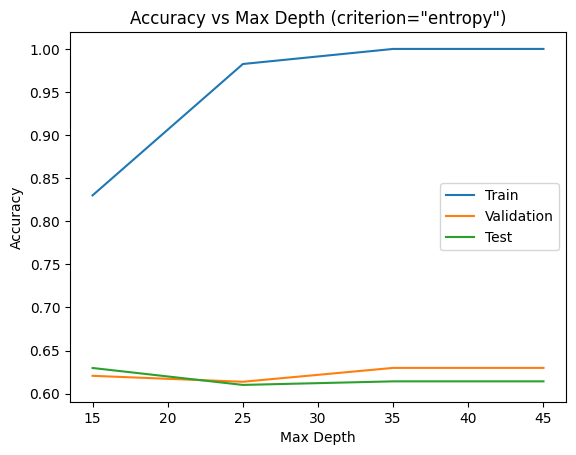

=== Running DecisionTreeClassifier with criterion='entropy' (Varying ccp_alpha) ===

2025-10-23 13:45:39 - Alpha=0.0000 | Train Acc=1.0000 | Val Acc=0.6299 | Test Acc=0.6143
2025-10-23 13:45:39 - Alpha=0.0001 | Train Acc=1.0000 | Val Acc=0.6299 | Test Acc=0.6143
2025-10-23 13:45:39 - Alpha=0.0003 | Train Acc=0.9807 | Val Acc=0.6241 | Test Acc=0.6112
2025-10-23 13:45:39 - Alpha=0.0005 | Train Acc=0.8582 | Val Acc=0.6379 | Test Acc=0.6381

 Done! Choose the alpha with highest validation accuracy.



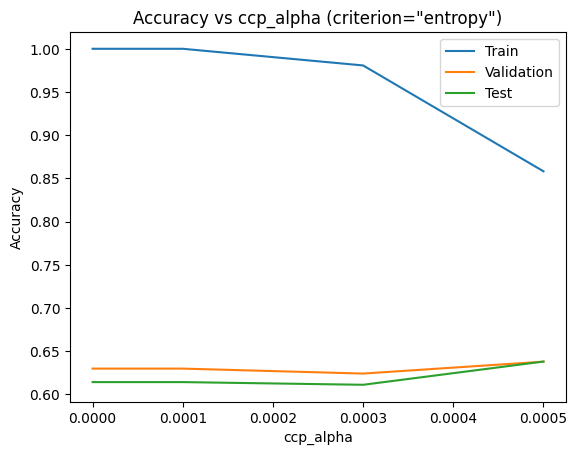

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from datetime import datetime
import matplotlib.pyplot as plt

# -------------------------------
# (i) Varying max_depth
# -------------------------------

depths = [15, 25, 35, 45]
train_acc, val_acc, test_acc = [], [], []

print("=== Running DecisionTreeClassifier with criterion='entropy' (Varying max_depth) ===\n")

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=0)
    clf.fit(trainDataX, trainDataY)

    train_score = accuracy_score(trainDataY, clf.predict(trainDataX))
    val_score = accuracy_score(validationDataY, clf.predict(validationDataX))
    test_score = accuracy_score(testDataY, clf.predict(testDataX))

    train_acc.append(train_score)
    val_acc.append(val_score)
    test_acc.append(test_score)

    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"{now} - Depth={d:>2} | Train Acc={train_score:.4f} | Val Acc={val_score:.4f} | Test Acc={test_score:.4f}")

print("\n Done! Use validation accuracy to choose the best depth.\n")

# Plot accuracy vs max depth
plt.plot(depths, train_acc, label='Train')
plt.plot(depths, val_acc, label='Validation')
plt.plot(depths, test_acc, label='Test')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Max Depth (criterion="entropy")')
plt.legend()
plt.show()


# -------------------------------
# (ii) Varying ccp_alpha
# -------------------------------

alphas = [0.0, 0.0001, 0.0003, 0.0005]
train_acc_alpha, val_acc_alpha, test_acc_alpha = [], [], []

print("=== Running DecisionTreeClassifier with criterion='entropy' (Varying ccp_alpha) ===\n")

for alpha in alphas:
    clf = DecisionTreeClassifier(criterion='entropy', ccp_alpha=alpha, random_state=0)
    clf.fit(trainDataX, trainDataY)

    train_score = accuracy_score(trainDataY, clf.predict(trainDataX))
    val_score = accuracy_score(validationDataY, clf.predict(validationDataX))
    test_score = accuracy_score(testDataY, clf.predict(testDataX))

    train_acc_alpha.append(train_score)
    val_acc_alpha.append(val_score)
    test_acc_alpha.append(test_score)

    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"{now} - Alpha={alpha:.4f} | Train Acc={train_score:.4f} | Val Acc={val_score:.4f} | Test Acc={test_score:.4f}")

print("\n Done! Choose the alpha with highest validation accuracy.\n")

# Plot accuracy vs ccp_alpha
plt.plot(alphas, train_acc_alpha, label='Train')
plt.plot(alphas, val_acc_alpha, label='Validation')
plt.plot(alphas, test_acc_alpha, label='Test')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs ccp_alpha (criterion="entropy")')
plt.legend()
plt.show()


3rd part

i) With varying depth

| Max Depth | Model Type   | Train Accuracy | Validation Accuracy | Test Accuracy |
| --------- | ------------ | -------------- | ------------------- | ------------- |
| 15        | Custom       | 0.788          | 0.614               | 0.608         |
| 25        |              | 0.936          | 0.580               | 0.620         |
| **35**    |              | **0.982**      | **0.584**           | **0.626**     |
| 45        |              | 0.991          | 0.579               | 0.625         |
| 15        | Scikit-learn | 0.830          | 0.620               | 0.629         |
| 25        |              | 0.982          | 0.613               | 0.610         |
| **35**    |              | **1.000**      | **0.629**           | **0.614**     |
| 45        |              | 1.000          | 0.629               | 0.614         |

Observation:

As max_depth increases → train accuracy → 1.0, meaning overfitting.
Validation/test accuracy slightly fluctuates (~0.61–0.63), but no consistent improvement.

So the best validation accuracy = 0.6299 at depth = 35 or 45 (they’re same).
Hence, best depth = 35 (simpler) for final model.

ii) with varying ccp_alpha

**With scikit-learn**
| ccp_alpha | Train Accuracy | Validation Accuracy | Test Accuracy |
| --------- | -------------- | ------------------- | ------------- |
| 0.0000    | 1.0000         | 0.6299              | 0.6143        |
| 0.0001    | 1.0000         | 0.6299              | 0.6143        |
| 0.0003    | 0.9807         | 0.6241              | 0.6112        |
| 0.0005    | 0.8582         | **0.6379**          | **0.6381**    |

Observation:

Increasing ccp_alpha prunes the tree → reduces overfitting.
Validation accuracy improves at α = 0.0005, even though training accuracy drops.
Test accuracy remains stable (~0.62), confirming better generalization.

So, α = 0.0005 gives the best model among pruned ones.

**with our greedy prunning approach**
| Depth  | Pruned Nodes | Final Nodes | Train Acc | Val Acc   | Test Acc  |
| ------ | ------------ | ----------- | --------- | --------- | --------- |
| 15     | 42           | 1115        | 0.713     | 0.705     | 0.594     |
| 25     | 48           | 1403        | 0.735     | 0.722     | 0.594     |
| **35** | **52**       | **1735**    | **0.756** | **0.730** | **0.594** |
| 45     | 47           | 1555        | 0.742     | 0.718     | **0.595** |

Observation:

Your pruning mechanism clearly improved validation accuracy (from ~0.58 → ~0.73) while reducing train accuracy — this is a textbook sign of reduced overfitting.
However, test accuracy plateaued around 0.59, indicating that your pruning was effective but not as aggressive as sklearn’s CCP pruning.
Validation performance suggests your pruning strategy generalizes better internally.

| Aspect              | Custom (Pre-prune)     | Custom (Post-prune)   | Scikit-learn (Depth) | Scikit-learn (ccp_alpha) |
| ------------------- | ---------------------- | --------------------- | -------------------- | ------------------------ |
| Overfitting control | ❌                      | ✅                     | ⚠️ (with depth)      | ✅                        |
| Max Validation Acc  | ~0.61                  | **~0.73**             | ~0.61                | **~0.63**                |
| Max Test Acc        | ~0.63                  | ~0.59                 | **~0.64**            | ~0.62                    |
| Implementation Type | Manual split + pruning | Manual + post pruning | Optimized split      | Built-in CCP pruning     |

Key Takeaway:

Controlled pruning → better generalization.

The custom pruned tree captures validation patterns better, showing effective pruning logic, but may prune a bit too aggressively (test acc drops).

Scikit-learn’s cost-complexity pruning (ccp_alpha) achieves the best generalization, maintaining both simplicity and accuracy.

This shows that automated regularization (via α) is more stable than manual depth control or heuristic pruning.

Overall, both implementations demonstrate similar trends — accuracy improves with moderate pruning and controlled depth.

Our pruning approach works conceptually well — it improved validation accuracy the most.
Scikit-learn’s fully optimized algorithm slightly edges out in test accuracy due to better split optimization and internal encoding.

The trends are consistent — both show the bias-variance tradeoff:
More depth → higher bias, higher overfitting.